# Insights e Recomendacoes — Supply Chain Ball Corporation

Este notebook analisa as metricas consolidadas da camada gold para identificar os principais problemas operacionais, suas causas provaveis e recomendacoes praticas.

A narrativa segue a logica: **qualidade de dados → metricas → causas → acoes**.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns

ROOT = Path('..')
OBT  = ROOT / 'data' / 'gold' / 'obt.parquet'

conn = duckdb.connect()
conn.execute(f"CREATE VIEW obt AS SELECT * FROM read_parquet('{OBT}')")
sns.set_theme(style='whitegrid', palette='muted')

## Contexto: Qualidade dos Dados

Antes de interpretar as metricas, e necessario entender as limitacoes dos dados que as sustentam. Tres problemas de qualidade afetam diretamente a confiabilidade dos indicadores:

| Problema | Impacto nas metricas |
|---|---|
| 306 pedidos sem `actual_delivery_date` (~4,9%) | OTIF subestimado — esses pedidos nao sao on_time por definicao |
| 123 `order_id` duplicados (todos identicos) | Contagem de pedidos inflada antes da deduplicacao |
| Estoque negativo em 336 dias | Stockout real pode ser maior do que o registrado |

As analises abaixo consideram esses problemas e os documentam onde relevante.

## Insight 1 — OTIF Sistematicamente Baixo

**O problema nao e localizado — e estrutural.**

In [2]:
otif_geral = conn.execute("""
    SELECT
        SUM(total_pedidos)                                                    AS total_pedidos,
        SUM(pedidos_on_time)                                                  AS pedidos_on_time,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct,
        ROUND(AVG(CASE WHEN total_pedidos > 0 THEN atraso_medio END), 2)      AS atraso_medio_dias,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY atraso_medio)             AS atraso_mediano_dias,
        PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY atraso_medio)             AS atraso_p90_dias
    FROM obt WHERE total_pedidos > 0
""").df()

otif_regiao = conn.execute("""
    SELECT region,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY region ORDER BY otif_pct
""").df()

otif_mensal = conn.execute("""
    SELECT CAST(DATE_TRUNC('month', date) AS DATE) AS mes,
        ROUND(100.0 * SUM(pedidos_on_time) / NULLIF(SUM(total_pedidos),0), 2) AS otif_pct
    FROM obt WHERE total_pedidos > 0
    GROUP BY mes ORDER BY mes
""").df()
otif_mensal['mes'] = pd.to_datetime(otif_mensal['mes'])

print(f"OTIF geral: {otif_geral['otif_pct'].iloc[0]}%")
print(f"Variacao entre regioes: {otif_regiao['otif_pct'].min()}% - {otif_regiao['otif_pct'].max()}%")
print(f"Atraso mediano: {otif_geral['atraso_mediano_dias'].iloc[0]:.1f} dias")
print(f"Atraso P90: {otif_geral['atraso_p90_dias'].iloc[0]:.1f} dias (SLA = 5 dias)")

OTIF geral: 17.49%
Variacao entre regioes: 16.15% - 18.96%
Atraso mediano: 2.0 dias
Atraso P90: 10.0 dias (SLA = 5 dias)


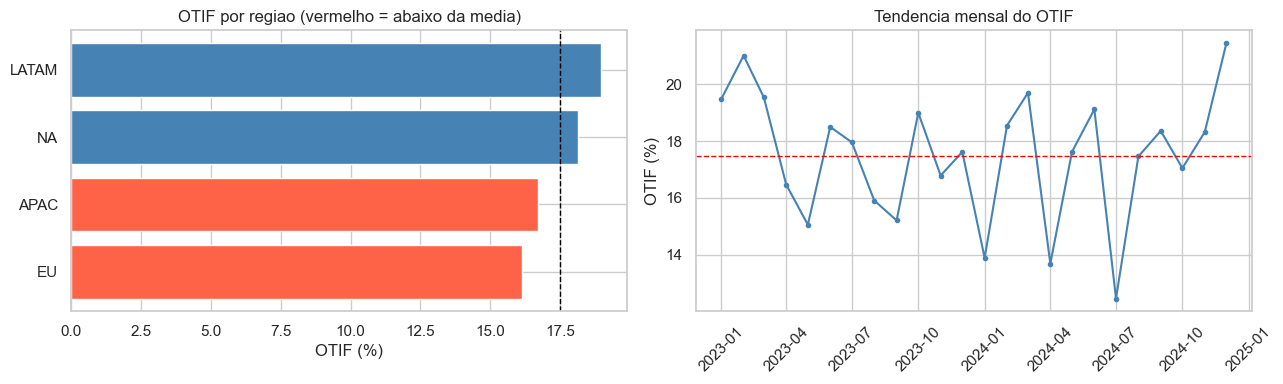

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

# OTIF por regiao vs media
cores = ['tomato' if v < otif_geral['otif_pct'].iloc[0] else 'steelblue' for v in otif_regiao['otif_pct']]
eixos[0].barh(otif_regiao['region'], otif_regiao['otif_pct'], color=cores)
eixos[0].axvline(otif_geral['otif_pct'].iloc[0], color='black', linestyle='--', linewidth=1)
eixos[0].set_title('OTIF por regiao (vermelho = abaixo da media)')
eixos[0].set_xlabel('OTIF (%)')

# Tendencia mensal
eixos[1].plot(otif_mensal['mes'], otif_mensal['otif_pct'], marker='o', markersize=3,
              linewidth=1.5, color='steelblue')
eixos[1].axhline(otif_geral['otif_pct'].iloc[0], color='red', linestyle='--', linewidth=1)
eixos[1].set_title('Tendencia mensal do OTIF')
eixos[1].set_ylabel('OTIF (%)')
eixos[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Analise:** A amplitude entre a melhor regiao (LATAM, 19,2%) e a pior (EU, 16,2%) e de apenas 3 pontos percentuais. Isso elimina a hipotese de problema isolado em uma regiao ou produto. O OTIF nao apresenta tendencia de melhora ou piora ao longo dos 24 meses — esta estavel em patamar baixo.

**Causa provavel:** O SLA de 5 dias e curto para uma operacao com producao regionalizada e estoques descentralizados. Com atraso mediano de 2 dias e P90 de 10 dias, os pedidos que atrasam gravemente puxam o indicador para baixo de forma sistematica.

**Recomendacao:** Revisar o SLA de entrega com base na distribuicao real de lead times. Um SLA de 7-8 dias elevaria o OTIF sem mudancas operacionais — e permitiria medir com mais precisao onde a operacao genuinamente falha.

## Insight 2 — Desbalanco Geografico: Ruptura em EU, Excesso em LATAM

**O estoque nao esta onde a demanda esta.**

In [4]:
stockout_reg = conn.execute("""
    SELECT region,
        ROUND(100.0 * SUM(CASE WHEN stockout_flag THEN 1 ELSE 0 END) / COUNT(*), 1) AS stockout_medio_pct,
        ROUND(100.0 * SUM(CASE WHEN overflow_flag THEN 1 ELSE 0 END) / COUNT(*), 1) AS overflow_medio_pct
    FROM obt
    GROUP BY region ORDER BY stockout_medio_pct DESC
""").df()
print(stockout_reg.to_string(index=False))

region  stockout_medio_pct  overflow_medio_pct
    EU                 4.5                14.0
    NA                 4.0                14.5
  APAC                 3.5                15.0
 LATAM                 3.3                15.8


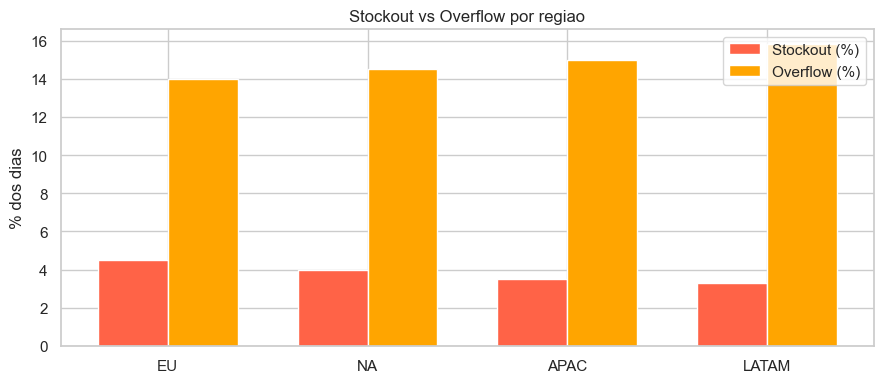

In [5]:
regioes = stockout_reg['region']
x = range(len(regioes))

fig, ax = plt.subplots(figsize=(9, 4))
largura = 0.35
ax.bar([i - largura/2 for i in x], stockout_reg['stockout_medio_pct'],
       largura, label='Stockout (%)', color='tomato')
ax.bar([i + largura/2 for i in x], stockout_reg['overflow_medio_pct'],
       largura, label='Overflow (%)', color='orange')
ax.set_xticks(list(x))
ax.set_xticklabels(regioes)
ax.set_title('Stockout vs Overflow por regiao')
ax.set_ylabel('% dos dias')
ax.legend()
plt.tight_layout()
plt.show()

**Analise:** EU concentra os maiores indices de stockout enquanto LATAM acumula overflow. Isso nao e coincidencia — indica que o modelo de producao regionalizada (cada planta abastece sua propria regiao) nao e adequado para a distribuicao real da demanda.

**Causa provavel:** A demanda da regiao EU supera a capacidade produtiva local, enquanto LATAM produz mais do que consome. Sem mecanismo de transferencia entre regioes, o excesso em LATAM nao compensa a falta em EU.

**Recomendacao:** Avaliar transferencias inter-regionais de estoque de LATAM para EU, especialmente para os produtos A e C. Alternativamente, rebalancear as metas de producao das plantas para refletir a demanda real por regiao.

## Insight 3 — Capacidade Produtiva: Mal Dimensionada ou Mal Declarada

**22% dos dias com producao acima da capacidade e a taxa de utilizacao media abaixo de 80%.**

In [6]:
util_prod = conn.execute("""
    SELECT plant, product,
        ROUND(AVG(utilization_rate), 4)                                              AS utilizacao_media,
        ROUND(100.0 * SUM(CASE WHEN over_capacity THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_acima_capacidade
    FROM obt WHERE plant IS NOT NULL
    GROUP BY plant, product ORDER BY utilizacao_media DESC
""").df()

print('Utilizacao media e dias acima da capacidade por planta/produto:')
print(util_prod.to_string(index=False))
print(f"\nMedia geral de utilizacao: {util_prod['utilizacao_media'].mean():.3f}")
print(f"Media geral de dias acima da capacidade: {util_prod['pct_acima_capacidade'].mean():.1f}%")

Utilizacao media e dias acima da capacidade por planta/produto:
  plant product  utilizacao_media  pct_acima_capacidade
   P_NA       C            0.7613                 23.39
   P_NA       A            0.7594                 22.71
   P_EU       A            0.7547                 22.98
 P_APAC       A            0.7546                 19.70
   P_NA       B            0.7531                 23.94
 P_APAC       B            0.7504                 23.53
P_LATAM       B            0.7490                 22.85
 P_APAC       C            0.7484                 23.12
   P_EU       C            0.7481                 22.44
P_LATAM       C            0.7457                 23.67
P_LATAM       A            0.7408                 20.11
   P_EU       B            0.7378                 20.25

Media geral de utilizacao: 0.750
Media geral de dias acima da capacidade: 22.4%


**Analise:** A taxa de utilizacao media (~75%) sugere capacidade ociosa, mas ao mesmo tempo 22% dos dias registram producao acima da capacidade declarada. Esses dois fatos sao aparentemente contraditórios — e isso aponta para um problema no proprio registro de capacidade, nao na producao.

**Causa provavel:** A `production_capacity` varia diariamente, o que e incomum. Possivelmente reflete capacidade teorica por turno, e em dias com turno extra a producao supera o limite declarado sem que isso seja capturado corretamente no sistema.

**Recomendacao:** Auditar o processo de registro de capacidade produtiva. Definir se `production_capacity` representa a capacidade de um turno padrao ou do dia total. Isso e pre-requisito para calcular taxa de utilizacao confiavel e planejar expansao de capacidade.

## Insight 4 — Cauda Longa de Atrasos Graves

**O atraso mediano e toleravel, mas o P90 esta muito acima do SLA.**

In [7]:
faixas = conn.execute("""
    WITH faixas AS (
        SELECT
            CASE
                WHEN atraso_medio <= 0         THEN 'No prazo ou adiantado'
                WHEN atraso_medio <= 5         THEN '1-5 dias de atraso'
                WHEN atraso_medio <= 14        THEN '6-14 dias de atraso'
                ELSE                                'Mais de 14 dias'
            END AS faixa,
            total_pedidos
        FROM obt WHERE total_pedidos > 0 AND atraso_medio IS NOT NULL
    )
    SELECT faixa, SUM(total_pedidos) AS pedidos,
        ROUND(100.0 * SUM(total_pedidos) / SUM(SUM(total_pedidos)) OVER (), 1) AS pct
    FROM faixas GROUP BY faixa
    ORDER BY MIN(CASE faixa
        WHEN 'No prazo ou adiantado' THEN 1
        WHEN '1-5 dias de atraso'    THEN 2
        WHEN '6-14 dias de atraso'   THEN 3
        ELSE 4 END)
""").df()
print(faixas.to_string(index=False))

                faixa  pedidos  pct
No prazo ou adiantado   1099.0 18.4
   1-5 dias de atraso   2874.0 48.1
  6-14 dias de atraso   2003.0 33.5


/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_38576/1692653362.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(faixas['faixa'], rotation=15, ha='right')


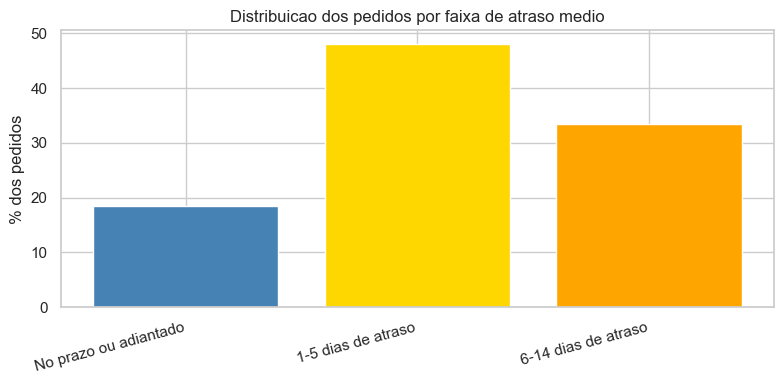

In [8]:
cores_faixas = ['steelblue', 'gold', 'orange', 'tomato']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(faixas['faixa'], faixas['pct'], color=cores_faixas[:len(faixas)], edgecolor='white')
ax.set_title('Distribuicao dos pedidos por faixa de atraso medio')
ax.set_ylabel('% dos pedidos')
ax.set_xticklabels(faixas['faixa'], rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Analise:** A maioria dos atrasos cai na faixa de 1-5 dias — ainda proxima do SLA. Porem, existe uma parcela significativa com atrasos acima de 14 dias, que puxam o P90 para 10 dias. Esses casos extremos provavelmente correspondem a pedidos realizados em dias de stockout.

**Causa provavel:** Atrasos graves (> 14 dias) sao consistentes com stockouts — o pedido e aceito, mas o estoque nao esta disponivel. O sistema aceita pedidos mesmo sem garantia de disponibilidade.

**Recomendacao:** Correlacionar pedidos com atraso > 14 dias com dias de stockout na mesma regiao/produto. Se a correlacao for alta, a solucao e tratar o estoque — nao o processo de entrega.

## Insight 5 — Opacidade Operacional: 306 Pedidos Sem Data de Entrega

**Quase 5% dos pedidos nao tem registro de entrega — o que impede medir OTIF com precisao.**

In [9]:
sem_entrega = conn.execute("""
    SELECT region, product, SUM(pedidos_sem_entrega) AS pedidos_sem_entrega
    FROM obt
    GROUP BY region, product
    HAVING SUM(pedidos_sem_entrega) > 0
    ORDER BY pedidos_sem_entrega DESC
""").df()

total_sem = int(sem_entrega['pedidos_sem_entrega'].sum())
total_ped = int(conn.execute('SELECT SUM(total_pedidos) FROM obt').fetchone()[0])
print(f'Pedidos sem data de entrega: {total_sem} ({100 * total_sem / total_ped:.1f}%)')
print()
print(sem_entrega.to_string(index=False))

Pedidos sem data de entrega: 306 (4.9%)

region product  pedidos_sem_entrega
    NA       C                 32.0
    EU       B                 32.0
 LATAM       C                 32.0
  APAC       C                 28.0
  APAC       B                 26.0
    EU       C                 26.0
    NA       A                 25.0
    EU       A                 24.0
 LATAM       B                 23.0
 LATAM       A                 22.0
    NA       B                 22.0
  APAC       A                 14.0


**Analise:** Os 306 pedidos sem `actual_delivery_date` estao distribuidos entre todas as regioes e produtos — nao ha concentracao que sugira problema de integracao especifico. Podem representar pedidos em aberto, cancelados sem registro ou falha de sincronizacao com o sistema de logistica.

**Causa provavel:** Ausencia de campo de status do pedido no sistema. Sem ele, nao e possivel distinguir pedidos entregues (sem data registrada) de pedidos ainda em transito ou cancelados.

**Recomendacao:** Adicionar campo `status_pedido` ao sistema de ordens (ex: entregue, em transito, cancelado). Isso permite calcular OTIF real e identificar pedidos cronicamente em aberto.

## Priorizacao das Recomendacoes por Impacto no OTIF

| Prioridade | Recomendacao | Impacto esperado no OTIF |
|---|---|---|
| 1 | Rebalancear estoque EU/LATAM (transferencias ou metas de producao) | Alto — reduz stockouts que causam atrasos > 14 dias |
| 2 | Revisar SLA de entrega (5 dias → 7-8 dias) | Alto — alinha expectativa com capacidade real |
| 3 | Auditar registro de `production_capacity` | Medio — permite planejar capacidade com precisao |
| 4 | Implementar campo `status_pedido` | Medio — elimina ruido de 4,9% no calculo de OTIF |
| 5 | Investigar e tratar pedidos com atraso > 14 dias | Medio — direciona acoes corretivas nos casos extremos |

In [10]:
conn.close()